<a href="https://colab.research.google.com/github/pamela-cp/York-Footfall-Data/blob/main/notebooks/York_Footfall_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The Request

The Request
York Footfall Data

We are taking the role of a promoter in York who is deciding what is the best location to place their stall so that the most people walk by it. To do this we are going to use daily footfall data. This data comes from cameras that automatically measure the number of people who walk past a particular location: the “footfall”.

Section 1

1. Load in the data and check it for integrity/quality.
2. Provide a summary table that shows the following for each location where footfall was measured:

    - The date of the first and last day when footfall was measured at this location
    - The mean daily footfall
    - The standard deviation of the daily footfall
    - The highest daily footfall
    - The lowest daily footfall
   
For all tasks from this point onwards, you should only use data from the year 2019 (the last full year
before the COVID pandemic).

3. Plot the distribution of footfall across all days in the dataset. This should show the distributions
   separated by the locations where footfall is measured (i.e. for each LocationName).
4. Perform a t-test to compare the footfall on Coney Street to Stonegate.
5. Perform an additional t-test to compare the footfall on Coney Street to Stonegate only on weekends (i.e. Saturdays/Sundays).

Section 2

1. What would you advise the promoter about whether they should place their stall on Coney Street or
Stonegate to maximise the number of passers by:

    - If they were doing so every day of the week
    - If they were doing so only at weekends


# Dependencies

In [15]:
%%R
install.packages('kableExtra')
library(tidyverse)
library(ggplot2)
library(kableExtra)
options(width=100)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/kableExtra_1.4.0.tar.gz'
Content type 'application/x-gzip' length 1824636 bytes (1.7 MB)
downloaded 1.7 MB


The downloaded source packages are in
	‘/tmp/Rtmp97i3Ud/downloaded_packages’


# Data dictionary

The data used for the analysis comes from the daily number of footfall recorded by cameras located in York. The variables are described in the following table:

Variable | Description
------------- | -------------
Date| The date of the recording
SiteName| The site where the recording took place
LocationName| The location of the recording
Weekday| The weekday of the recording
TotalCount| The total number of footfall recorded
Recording_ID| The ID of the recording


---

# Section 1

1. Load in the data and check it for integrity/quality.

In [1]:
from google.colab import files

print("Please upload the 'York_Footfall_data.csv' file.")
files.upload()

%pip install rpy2
%load_ext rpy2.ipython

Please upload the 'York_Footfall_data.csv' file.


Saving York_Footfall_data.csv to York_Footfall_data.csv


Rows: 8204 Columns: 6
── Column specification ────────────────────────────────────────────────────────────────────────────
Delimiter: ","
chr  (3): SiteName, LocationName, WeekDay
dbl  (2): TotalCount, Recording_ID
date (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
        Date     SiteName LocationName      WeekDay   TotalCount Recording_ID 
           0            0            0            0           10          100 
        Date     SiteName LocationName      WeekDay   TotalCount Recording_ID 
           0            0            0            0            0            0 
# A tibble: 0 × 4
# ℹ 4 variables: SiteName <chr>, LocationName <chr>, Date <date>, count <int>
# A tibble: 6 × 5
  SiteName LocationName             min_date   max_date   ndays
  <chr>    <chr>                    <date>     <date>     <int>
1 York     Church Street            2015-01-01 2017-06-18

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/kableExtra_1.4.0.tar.gz'
Content type 'application/x-gzip' length 1824636 bytes (1.7 MB)
downloaded 1.7 MB


The downloaded source packages are in
	‘/tmp/Rtmp97i3Ud/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/gridExtra_2.3.tar.gz'
Content type 'application/x-gzip' length 1062844 bytes (1.0 MB)
downloaded 1.0 MB


The downloaded source packages are in
	‘/tmp/Rtmp97i3Ud/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cran.rstudio.com/src/contrib/patchwork_1.3.2.tar.gz'
Content type 'application/x-gzip' length 3322521 bytes (3.2 MB)
downloaded 3.2 MB


The downloaded source packages are in
	‘/tmp/Rtmp97i3Ud/downloaded_packages’
Installing package into ‘/usr/local/lib/R/site-librar

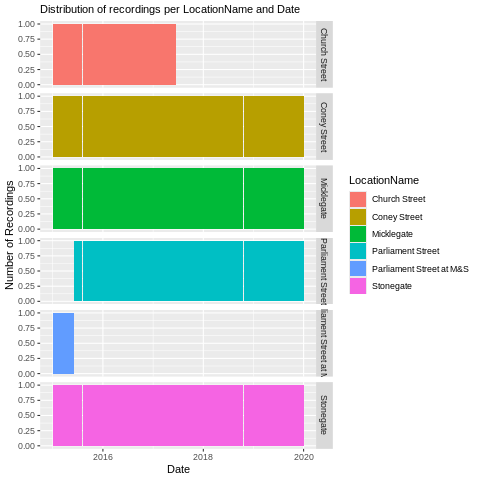

In [61]:
%%R

options(device = "png")

install.packages('kableExtra')
install.packages('gridExtra') # Added installation for gridExtra
install.packages('patchwork') # Added installation for patchwork
install.packages("IRdisplay")
install.packages("plotly")  # install plotly
library(tidyverse)
library(ggplot2)
library(kableExtra)
library(gridExtra)
library(patchwork) # Load patchwork after installation
library(htmltools)
library(IRdisplay)
library(plotly)


options(width=100)

options(repr.plot.width = 12, repr.plot.height = 6)

# 1.1: Load in the data
data <- read_csv("York_Footfall_data.csv",col_names = TRUE)

# 1.2: Check it for integrity/quality

# 1.2.1: Checking for missing values (NA values).
print(colSums(is.na(data)))

#        - There are 10 missing values in the TotalCount column and 100 in the Recording_ID column.
#        - In order to avoid affecting the analysis of footfall with missing values, these rows should be removed.
#        - Given that missing values in the Recording_ID do not have a meaningful effect on the analysis, it should remain in the data.

# 1.2.2: Checking for missing values (NaN values).
print(sapply(data, function(x) sum(is.nan(x))))

#        - There are not NaN values in the data.
#        - Used support of AI for finding the function

# 1.2.3: Checking for duplicate records.
print(data %>% group_by(SiteName,LocationName,Date) %>% filter(n() > 1) %>% summarize(count = n(),.groups = 'drop'))

#        - There are no results for duplicated data.

# 1.2.4: Checking for dates.

# 1.2.4.1: Visualising the distribution of recordings per Location and Date to search for duplicates and integrity of Date.
p1<-ggplot(data, aes(x=Date,fill=LocationName)) + geom_histogram(binwidth = 1) + facet_grid(LocationName~.) +
labs(x="Date", y="Number of Recordings", subtitle="Distribution of recordings per LocationName and Date")
print(p1)

#       - Footfall data for Church Street ceased in 2017.
#       - Parliament Street and Parliament Street at M&S may refer to the same physical location, as both were complementary recorded during the same period. Alternatively, the recording site may have changed from Parliament Street at M&S to another location. This data should be validated with its owners.

# 1.2.4.2: Creating a short summary of dates to see detail of the previous graph
print(data %>% group_by(SiteName,LocationName) %>% summarize(min_date = min(Date, na.rm = TRUE), max_date = max(Date, na.rm = TRUE), ndays=n(), .groups = 'drop'))

#       - The data for Church Street was recorded until 2017-06-18.
#       - Parliament Street at M&S has data until 2015-06-07, then from the next day forward there is data recorded in Parliament Street.


In addition: Warning message:
Removed 10 rows containing non-finite outside the scale range (`stat_bin()`). 


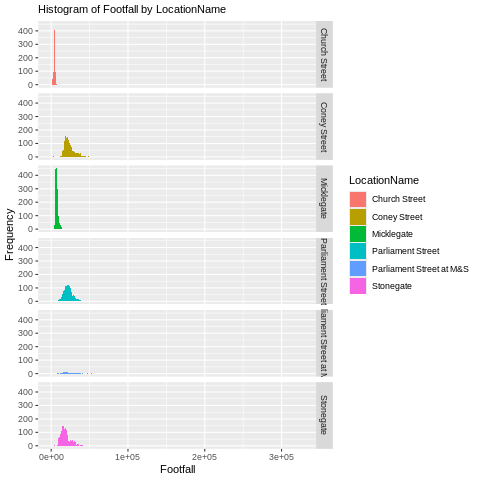

In [62]:
%%R

# 1.2.5: Checking for outliers using Histograms
p2<-ggplot(data, aes(x=TotalCount,fill=LocationName)) + geom_histogram(binwidth = 1000) + facet_grid(LocationName~.) + labs(x="Footfall", y="Frequency", subtitle="Histogram of Footfall by LocationName")
print(p2)

#       - There are 10 missing values in the TotalCount column that were removed from the graph.
#       - Significant outliers are present, but this graph lacks detail.


In addition: Warning message:
Removed 10 rows containing non-finite outside the scale range (`stat_boxplot()`). 


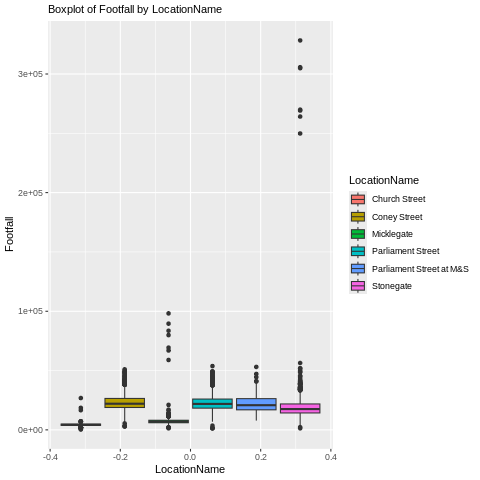

In [63]:
%%R

# 1.2.6: Checking for outliers using Boxplots
p3<-ggplot(data) + geom_boxplot(aes(y = TotalCount,fill=LocationName)) + labs(x="LocationName", y="Footfall", subtitle="Boxplot of Footfall by LocationName")
print(p3)

#       - There are 10 missing values in the TotalCount column that were removed from the graph.
#       - Significant outliers were observed in Stonegate with footfall greater than 200,000.
#       - Significant outliers were observed in Micklegate with footfall greater than 50,000.


         n
1 98.65919
         n
1 99.87811
# A tibble: 8,180 × 6
   Date       SiteName LocationName             WeekDay  TotalCount Recording_ID
   <date>     <chr>    <chr>                    <chr>         <dbl>        <dbl>
 1 2015-01-01 York     Church Street            Thursday       1952       375836
 2 2015-01-01 York     Coney Street             Thursday      12220       724862
 3 2015-01-01 York     Micklegate               Thursday       5559       451020
 4 2015-01-01 York     Parliament Street at M&S Thursday       7802       523989
 5 2015-01-01 York     Stonegate                Thursday      14004       382272
 6 2015-01-02 York     Church Street            Friday         3451       464381
 7 2015-01-02 York     Coney Street             Friday        31495       654292
 8 2015-01-02 York     Micklegate               Friday         7055       965489
 9 2015-01-02 York     Parliament Street at M&S Friday        25427       289782
10 2015-01-02 York     Stonegate           

In addition: Warning message:
Removed 10 rows containing missing values or values outside the scale range (`geom_col()`). 


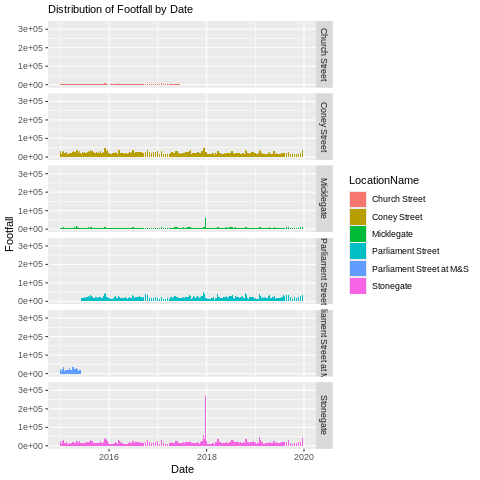

In [65]:
%%R

# 1.2.7: Validation of outliers considering seasonality effect
p4<-ggplot(data, aes(x=Date,y=TotalCount,fill=LocationName)) +
  geom_col() + facet_grid(LocationName~.) + labs(x="Date", y="Footfall", subtitle="Distribution of Footfall by Date")
print(p4)

#       - There are 10 missing values in the TotalCount column that were removed from the graph.
#       - Only a few outliers were observed in late 2017, which suggests it is not a recurring pattern and should be removed.

# 1.2.8:  Percentage of all data which is not available
print(count(na.omit(data))/count(data)*100)

# 1.2.9:  Percentage of data which is not available and affects the analysis (considers only missing values in the TotalCount column)
print(count(data%>%filter(!is.na(TotalCount)))/count(data)*100)

# 1.2.10:  Percentage of data after cleaning (considers removal of missing values in the TotalCount column and outliers)

# 1.2.10.1:   Data Cleaning
print(data_clean<-data%>%filter(!is.na(TotalCount),!((LocationName=="Micklegate" & TotalCount>50000) | (LocationName=="Stonegate" & TotalCount>200000))))


         n
1 99.70746


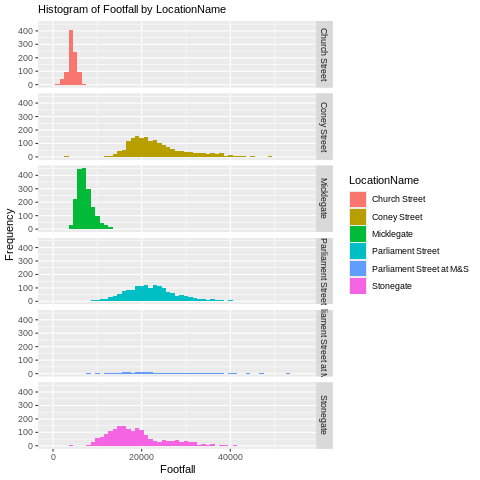

In [69]:
%%R

# 1.2.10.2:   Checking for outliers using Histograms after cleaning data
p5<-ggplot(data_clean, aes(x=TotalCount,fill=LocationName)) + geom_histogram(binwidth = 1000) + facet_grid(LocationName~.) + labs(x="Footfall", y="Frequency", subtitle="Histogram of Footfall by LocationName")
print(p5)

# 1.2.10.3:   Calculating percentage of data after cleaning
print(count(data_clean)/count(data)*100)

# End of question 1